In [1]:
import pandas as pd

#df= pd.read_csv("set2_masses_without_anomalies.csv") 
df_all_shuffled_training_mass = pd.read_csv("set1_tracks_without_anomalies.csv") # training sample
df_all_shuffled_training_mass.head()


,InvariantMass,EventID,TrackID,N_sigma_e,N_sigma_mu,N_sigma_K,N_sigma_p
0,3.084596,1,1,-5.744735,-0.361855,0.519927,-2.389182
1,3.084596,1,2,-6.464739,-1.439880,-0.587748,-3.255837
2,3.075432,2,1,-5.446293,0.081403,1.007799,-1.945412
3,3.075432,2,2,-5.294848,0.310762,1.219705,-1.824927
4,3.061298,4,1,-4.019822,2.215611,3.214369,-0.192263


In [2]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


I0000 00:00:1785342126.816644  249674 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785342126.860791  249674 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785342128.014196  249674 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
#------------------------------------------
# 1. Load and Prepare the Data
#------------------------------------------

X=df_all_shuffled_training_mass[['N_sigma_e','N_sigma_mu', 'N_sigma_K', 'N_sigma_p', 'TrackID']].values
df_all_shuffled_training_mass.head()


,InvariantMass,EventID,TrackID,N_sigma_e,N_sigma_mu,N_sigma_K,N_sigma_p
0,3.084596,1,1,-5.744735,-0.361855,0.519927,-2.389182
1,3.084596,1,2,-6.464739,-1.439880,-0.587748,-3.255837
2,3.075432,2,1,-5.446293,0.081403,1.007799,-1.945412
3,3.075432,2,2,-5.294848,0.310762,1.219705,-1.824927
4,3.061298,4,1,-4.019822,2.215611,3.214369,-0.192263


In [4]:
# Extract mass separately
#mass = df['mass_true'].values

mass=df_all_shuffled_training_mass['InvariantMass'].values
# Create a train/test split

X_train, X_test, mass_train, mass_test = train_test_split(X, mass, test_size=0.05, random_state=42)

from sklearn.preprocessing import MinMaxScaler
#Initialize scaler

scaler = MinMaxScaler()
# Fit and transform training data, transform test data

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

import tensorflow as tf
print("TensorFlow version:", tf.version)
print("Available devices:", tf.config.list_physical_devices())
#tf.debugging.set_log_device_placement(True)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Disable GPU (if any)
#------------------------------------------
# 2. Define the Autoencoder Model
#------------------------------------------

input_dim = X_train.shape[1] # should be 6
encoding_dim = 2 # latent space dimension
# Input layer

input_layer = Input(shape=(input_dim,))
# Encoding layer (compression)

encoded = Dense(encoding_dim, activation='relu')(input_layer)
# Decoding layer (reconstruction)

decoded = Dense(input_dim, activation='sigmoid')(encoded)
# Autoencoder model

autoencoder = Model(inputs=input_layer, outputs=decoded)
#autoencoder.compile(optimizer='adam', loss='mse')

from tensorflow.keras.optimizers import Adam
#autoencoder.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # best, 185 epochs automatic stop
#------------------------------------------
# 3. Train the Autoencoder
#------------------------------------------

early_stopping = EarlyStopping(
monitor='val_loss',
patience=15,
restore_best_weights=True
)

history = autoencoder.fit(X_train, X_train,
epochs=100,
# epochs=500,
batch_size=256,
# batch_size=64,
shuffle=True,
validation_data=(X_test, X_test),
verbose=1,
callbacks=[early_stopping]
)
#with tf.device('/CPU:0'):
    #history = autoencoder.fit(X_train, X_train, epochs=500, batch_size=64, validation_data=(X_test, X_test), callbacks=[early_stopping], verbose=2)
print(f"Training stopped at epoch {len(history.history['loss'])}")

#print(f"Training stopped at epoch {len(history.history['loss'])}")


(408063, 5) (21477, 5)
TensorFlow version: <module 'tensorflow._api.v2.version' from '/home/valeriia-loboda/pythia/pythia8309/.venv/lib/python3.12/site-packages/tensorflow/_api/v2/version/__init__.py'>
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Epoch 1/100
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 712us/step - loss: 0.0448 - val_loss: 0.0154
Epoch 2/100
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - loss: 0.0121 - val_loss: 0.0100
Epoch 3/100
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - loss: 0.0071 - val_loss: 0.0035
Epoch 4/100
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 691us/step - loss: 0.0020 - val_loss: 0.0012
Epoch 5/100
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - loss: 0.0011 - val_loss: 9.7390e-04
Epoch 6/100
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step - loss: 9.7053e-04 - val_loss: 8.4207e-04
Epoch 7/100
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - loss: 8.8923e-04 - val_loss: 8.1340e-04
Epoch 8/100
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/ste

In [5]:
X_test_pred = autoencoder.predict(X_test)

mse_test = np.mean(
    np.square(X_test - X_test_pred),
    axis=1
)

mse_test = np.mean((X_test - X_test_pred)**2, axis=1)



672/672 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step


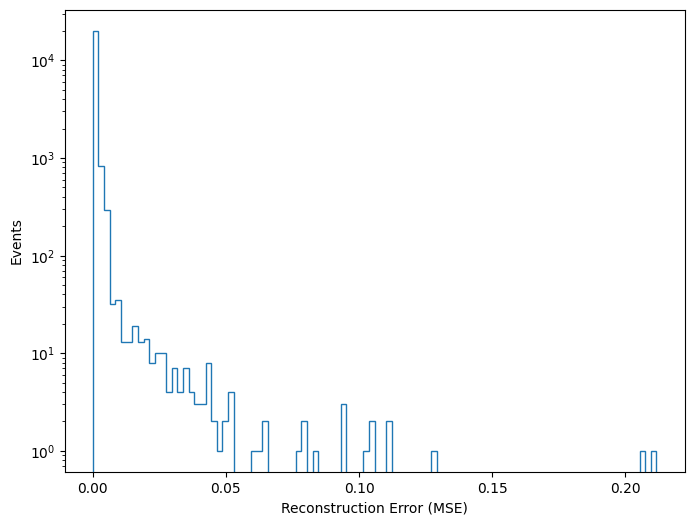

In [6]:
plt.figure(figsize=(8,6))

plt.hist(
    mse_test,
    bins=100,
    histtype='step'
)

plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Events')
plt.yscale('log')

plt.show()


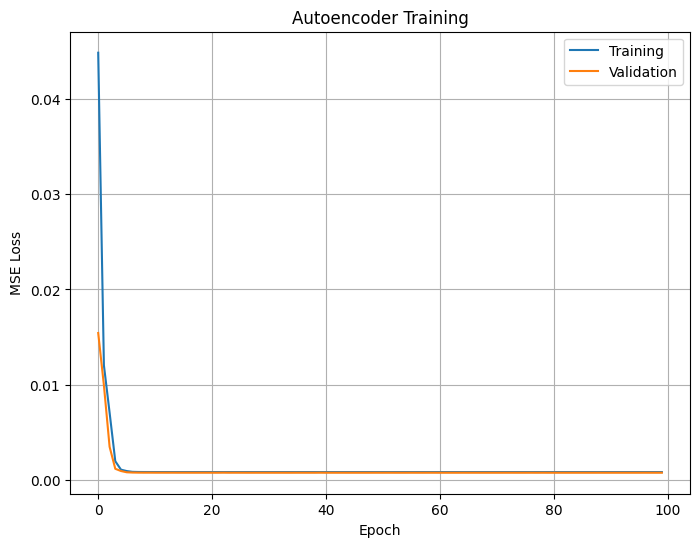

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training')
plt.legend()
plt.grid(True)

plt.savefig('validation_curve.png')
plt.show()


In [8]:
# Extract the features for the ENTIRE dataset (e.g., X_all)
X_all = scaler.transform(df_all_shuffled_training_mass[['N_sigma_e','N_sigma_mu', 'N_sigma_K', 'N_sigma_p', 'TrackID']].values)  # replace with your feature column names

# Predict on everything
X_all_pred = autoencoder.predict(X_all, verbose=0)

# Calculate MSE for all rows
mse_all = np.mean(np.square(X_all - X_all_pred), axis=1)

# Now the lengths match perfectly! (430,318 == 430,318)
df_results = df_all_shuffled_training_mass.copy()
df_results["reconstruction_error"] = mse_all

In [9]:
#threshold = np.percentile(mse_all, 99)
threshold = 0.001

df_results["is_anomaly"] = (
    df_results["reconstruction_error"] > threshold
)

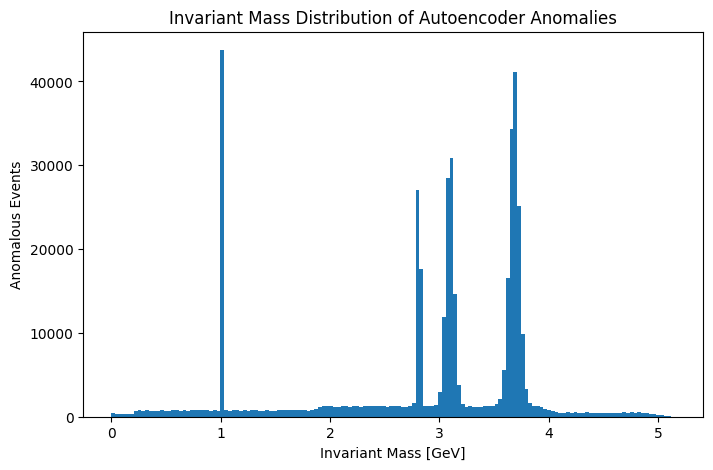

In [17]:
anomalous_events = df_results[
    df_results["is_anomaly"]
]

plt.figure(figsize=(8,5))

plt.hist(
    df_results["InvariantMass"],
    bins=150
)

plt.xlabel("Invariant Mass [GeV]")
plt.ylabel("Anomalous Events")
plt.title("Invariant Mass Distribution of Autoencoder Anomalies")


plt.show()

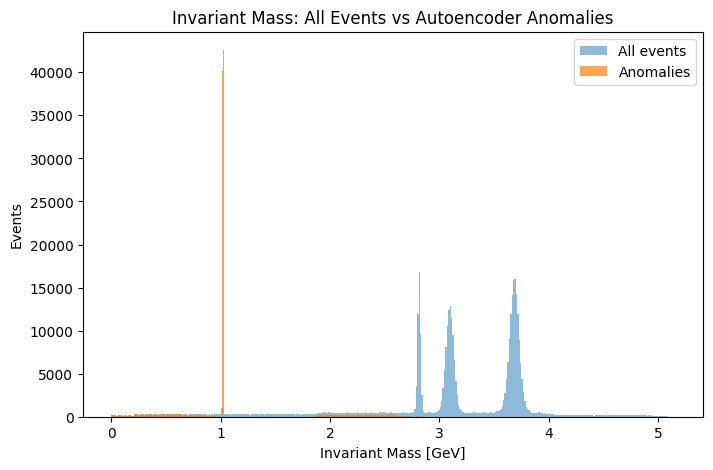

In [11]:
plt.figure(figsize=(8,5))

plt.hist(
    df_results["InvariantMass"],
    bins=400,
    alpha=0.5,
    label="All events"
)

plt.hist(
    anomalous_events["InvariantMass"],
    bins=400,
    alpha=0.7,
    label="Anomalies"
)

plt.xlabel("Invariant Mass [GeV]")
plt.ylabel("Events")
#plt.yscale("log")
plt.title("Invariant Mass: All Events vs Autoencoder Anomalies")
#plt.ylim(0, 10000)

plt.legend()

plt.show()

In [12]:
# Check count of normal vs anomaly rows
print("Total rows:", len(df_results))
print(df_results['is_anomaly'].value_counts(dropna=False))

Total rows: 429540
is_anomaly
False    363611
True      65929
Name: count, dtype: int64


Epoch 1/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - loss: 5.0168e-04 - val_loss: 0.0043
Epoch 2/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - loss: 5.0133e-04 - val_loss: 0.0044
Epoch 3/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - loss: 5.0051e-04 - val_loss: 0.0046
Epoch 4/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step - loss: 4.9870e-04 - val_loss: 0.0049
Epoch 5/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 722us/step - loss: 4.9566e-04 - val_loss: 0.0052
Epoch 6/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - loss: 4.9059e-04 - val_loss: 0.0055
Epoch 7/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 706us/step - loss: 4.8054e-04 - val_loss: 0.0065
Epoch 8/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step - loss: 4.6381e-04 - val_loss: 0.0071
Epoch 9/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step - loss: 4.6001e-04 - val_loss: 0.0072
Epoch 10/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 747us/step - loss: 4.5783e-04 - val_loss: 0.0073
Epoch 11/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 1s 75

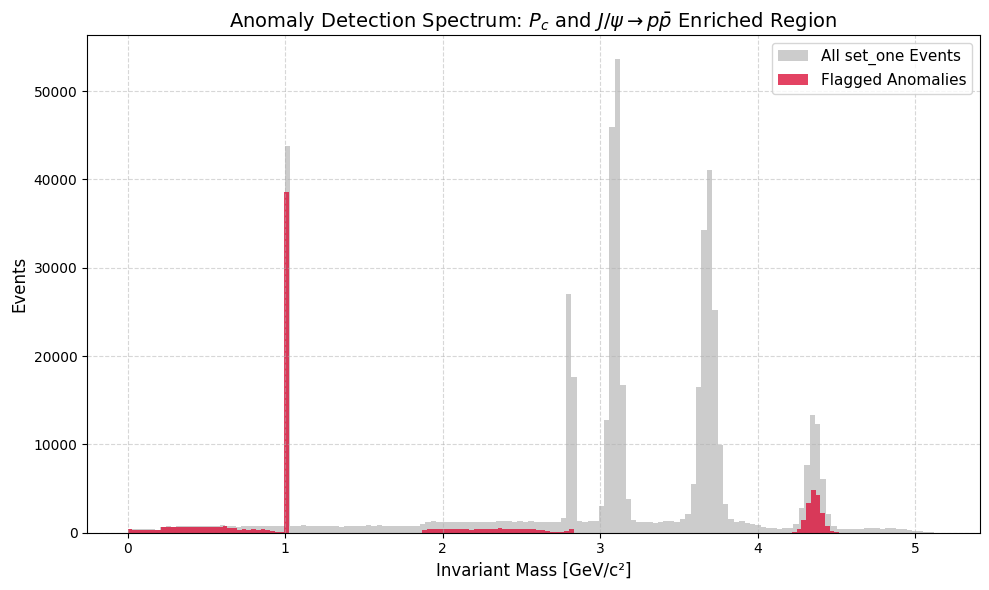

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# STEP 1: Train Autoencoder on set_one_clean
# ==========================================
# (Assuming 'scaler' and 'autoencoder' are defined)
X_clean_scaled = scaler.fit_transform(df_all_shuffled_training_mass[['N_sigma_e','N_sigma_mu', 'N_sigma_K', 'N_sigma_p', 'TrackID']].values)  # replace with your feature column names])

autoencoder.fit(
    X_clean_scaled,
    X_clean_scaled,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1,
)

# ==========================================
# STEP 2: Evaluate on set_one (Includes signals)
# ==========================================
# IMPORTANT: Use .transform(), NOT .fit_transform() here!
df_all = pd.read_csv("set1_tracks.csv") # training sample

X_set_one_scaled = scaler.transform(df_all[['N_sigma_e','N_sigma_mu', 'N_sigma_K', 'N_sigma_p', 'TrackID']].values)  # replace with your feature column names])

# Run inference
X_set_one_pred = autoencoder.predict(X_set_one_scaled)

# Compute Reconstruction Loss (MSE per event)
recon_loss = np.mean((X_set_one_scaled - X_set_one_pred) ** 2, axis=1)
df_all["recon_loss"] = recon_loss

# ==========================================
# STEP 3: Select Anomalies
# ==========================================
# Flag top 5% highest reconstruction loss events as anomalies
#percentile_cutoff = 95
threshold = 0.001

# Create boolean mask for anomalies
anomaly_mask = df_all["recon_loss"] > threshold
anomalies = df_all[anomaly_mask]

#print(f"Anomaly threshold ({percentile_cutoff}th percentile): {threshold:.4f}")
print(f"Total events in df_all: {len(df_all)}")
print(f"Flagged anomalies: {len(anomalies)}")

# ==========================================
# STEP 4: Plot Comparison
# ==========================================
plt.figure(figsize=(10, 6))

# Plot all events in set_one
plt.hist(
    df_all["InvariantMass"],
    bins=150,
    alpha=0.4,
    color="gray",
    label="All set_one Events",
    density=False,
)

# Overlay flagged anomaly events
plt.hist(
    anomalies["InvariantMass"],
    bins=150,
    alpha=0.8,
    color="crimson",
    label=f"Flagged Anomalies",
    density=False,
)

plt.xlabel("Invariant Mass [GeV/c²]", fontsize=12)
plt.ylabel("Events", fontsize=12)
plt.title(
    r"Anomaly Detection Spectrum: $P_c$ and $J/\psi \to p\bar{p}$ Enriched Region",
    fontsize=14,
)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("anomaly_detection_spectrum.png", dpi=300)
plt.show()

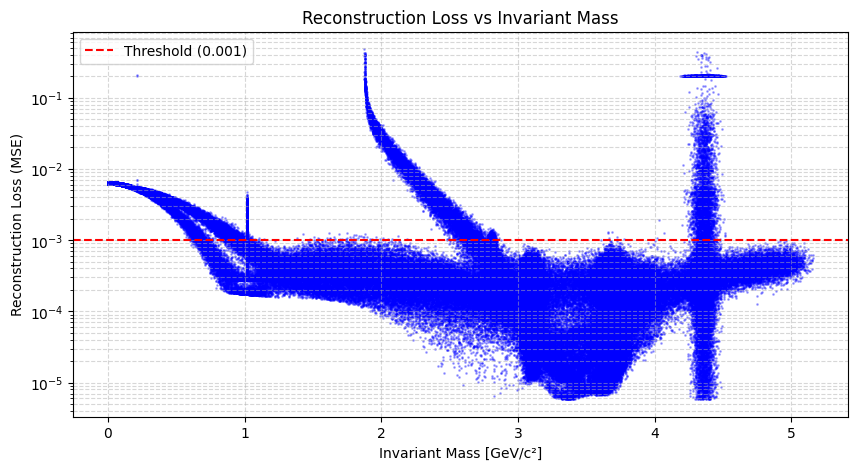

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(
    df_all["InvariantMass"], df_all["recon_loss"], s=1, alpha=0.3, c="blue"
)
plt.axhline(
    y=threshold,
    color="red",
    linestyle="--",
    label=f"Threshold ({threshold:.3f})",
)
plt.yscale("log")  # Log scale helps see loss differences
plt.xlabel("Invariant Mass [GeV/c²]")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("Reconstruction Loss vs Invariant Mass")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.savefig("reconstruction_loss_vs_mass.png", dpi=300)
plt.show()